DIAMOND PRICE PREDICTION

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

IMPORT DATASET AND READ DATASET USING PANDAS

In [2]:
data = pd.read_csv('diamonds.csv')
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


DATA PRE-PROCESSING

In [3]:
##Check for null values
data.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
##Check for duplicate data and drop
data.duplicated().sum()

np.int64(146)

In [7]:
data.drop_duplicates()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


OUTLIER DETECTION AND VISUALIZATION

In [8]:
data.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

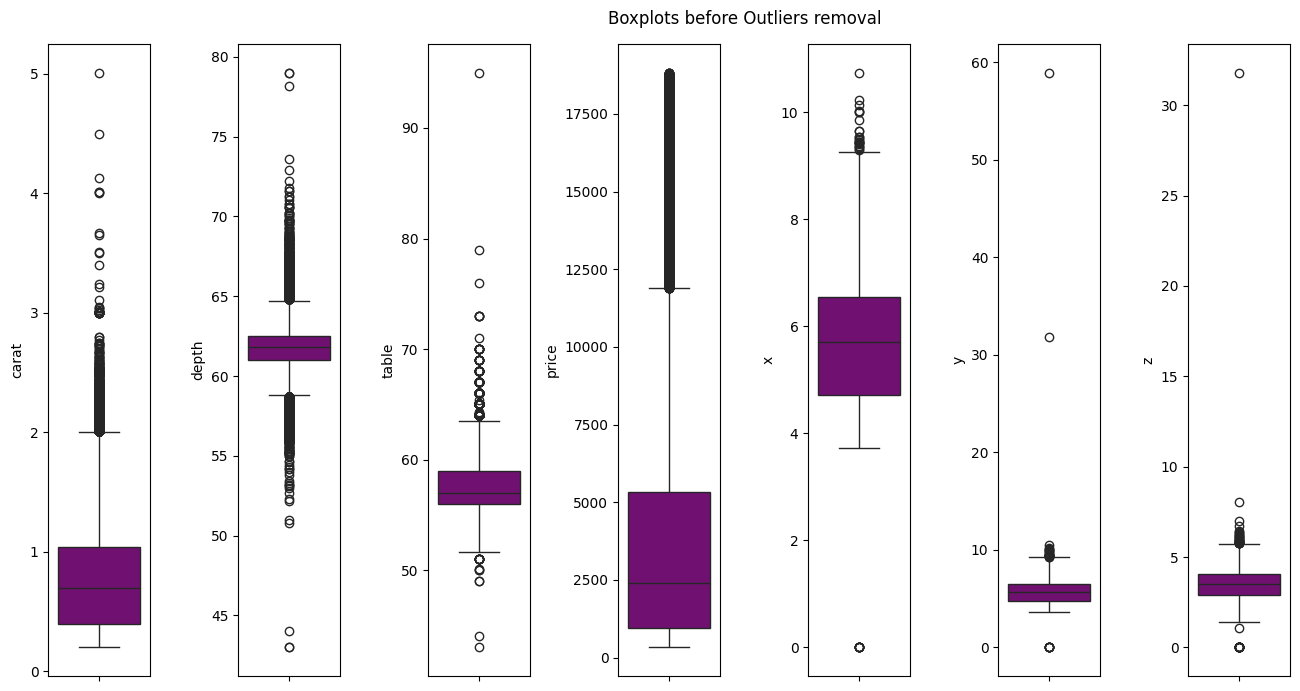

In [9]:
##Check for Outliers for numerical columns
numerical_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

plt.figure(figsize=(15, 7))
plt.suptitle("Boxplots before Outliers removal")
for i in range(0, len(numerical_cols)):
    plt.subplot(1, 8, i+1)
    sns.boxplot(y=data[numerical_cols[i]],color='purple')
    plt.tight_layout()

HANDLING OUTLIERS

In [10]:
##Calculate the IQR, Lower Bound, Upper Bound and Remove Outliers
for cols in numerical_cols:
    Q1 = data[cols].quantile(0.25)
    Q3 = data[cols].quantile(0.75)
    IQR = Q3 - Q1   
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[cols] = np.where(data[cols] < lower_bound, lower_bound, data[cols])
    data[cols] = np.where(data[cols] > upper_bound, upper_bound, data[cols])


VISUALIZING AFTER OUTLIER REMOVAL

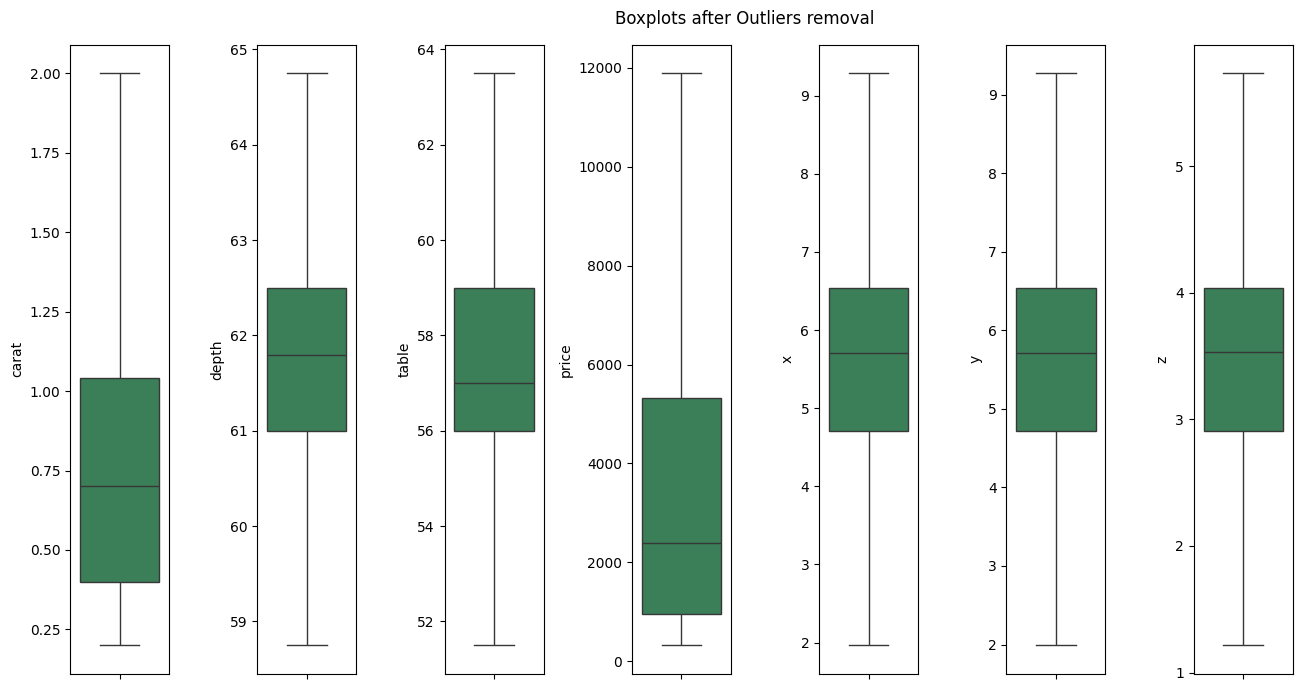

In [11]:
plt.figure(figsize=(15, 7))
plt.suptitle("Boxplots after Outliers removal")
for i in range(0, len(numerical_cols)):
    plt.subplot(1, 8, i+1)
    sns.boxplot(y=data[numerical_cols[i]],color='seagreen')
    plt.tight_layout()

CHECKING FOR SKEWNESS

In [12]:
data.shape

(53940, 10)

In [13]:
skewness = data.skew(numeric_only=True)
print(skewness)

carat    0.899893
depth   -0.228261
table    0.473306
price    1.148304
x        0.389029
y        0.385351
z        0.374472
dtype: float64


TRANSFORM SKEWED DATA WITH LOG TRANSFORMATION

In [14]:
data['carat'] = np.log1p(data['carat'])
data['price'] = np.log1p(data['price']) 


In [15]:
infinity_values = np.isinf(data[numerical_cols]).values.sum()
infinity_values

np.int64(0)

In [16]:
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,Ideal,E,SI2,61.50,55.0,5.789960,3.95,3.98,2.43
1,0.190620,Premium,E,SI1,59.80,61.0,5.789960,3.89,3.84,2.31
2,0.207014,Good,E,VS1,58.75,63.5,5.793014,4.05,4.07,2.31
3,0.254642,Premium,I,VS2,62.40,58.0,5.814131,4.20,4.23,2.63
4,0.270027,Good,J,SI2,63.30,58.0,5.817111,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,Ideal,D,SI1,60.80,57.0,7.922261,5.75,5.76,3.50
53936,0.542324,Good,D,SI1,63.10,55.0,7.922261,5.69,5.75,3.61
53937,0.530628,Very Good,D,SI1,62.80,60.0,7.922261,5.66,5.68,3.56
53938,0.620576,Premium,H,SI2,61.00,58.0,7.922261,6.15,6.12,3.74


DERIVING NEW COLUMNS 'Volume', 'Price per Carat', and 'Dimension ratio'

In [17]:
data['Volume'] = data['x']* data['y']* data['z']
data['Price per Carat'] = data['price']/ data['carat']
data['Dimension ratio'] = (data['x']+ data['y'])/ 2 * data['z']

In [18]:
data

,carat,cut,color,clarity,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio
0,0.207014,Ideal,E,SI2,61.50,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,9.63495
1,0.190620,Premium,E,SI1,59.80,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,8.92815
2,0.207014,Good,E,VS1,58.75,63.5,5.793014,4.05,4.07,2.31,38.076885,27.983657,9.37860
3,0.254642,Premium,I,VS2,62.40,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,11.08545
4,0.270027,Good,J,SI2,63.30,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,11.94875
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,Ideal,D,SI1,60.80,57.0,7.922261,5.75,5.76,3.50,115.920000,14.607978,20.14250
53936,0.542324,Good,D,SI1,63.10,55.0,7.922261,5.69,5.75,3.61,118.110175,14.607978,20.64920
53937,0.530628,Very Good,D,SI1,62.80,60.0,7.922261,5.66,5.68,3.56,114.449728,14.929965,20.18520
53938,0.620576,Premium,H,SI2,61.00,58.0,7.922261,6.15,6.12,3.74,140.766120,12.765970,22.94490


VISUALIZATION USING MATPLOTLIB, SNS

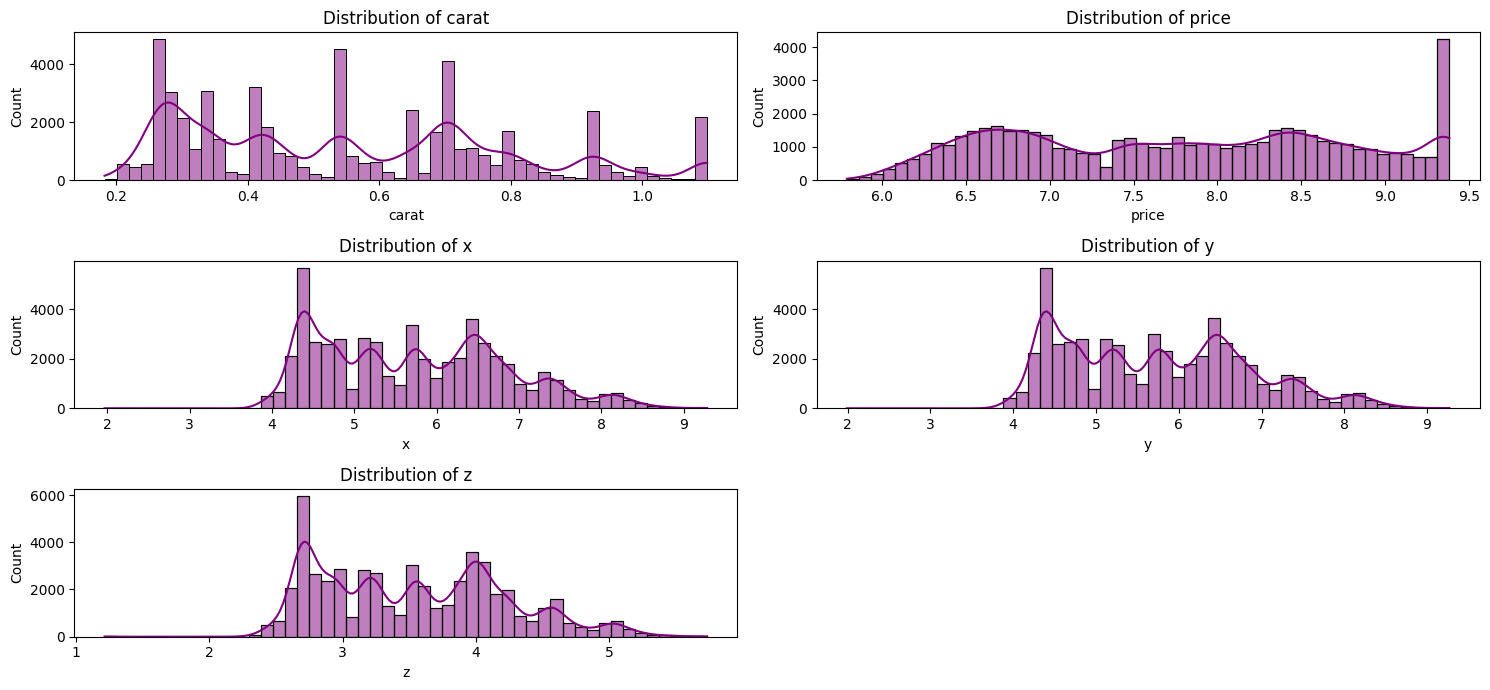

In [19]:
##Distribution of carat, price, x, y, z
numerical_features = ['carat', 'price', 'x', 'y', 'z']
plt.figure(figsize=(15, 7))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 2, i+1)
    sns.histplot(data[col], kde = True, bins = 50, color='purple')
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

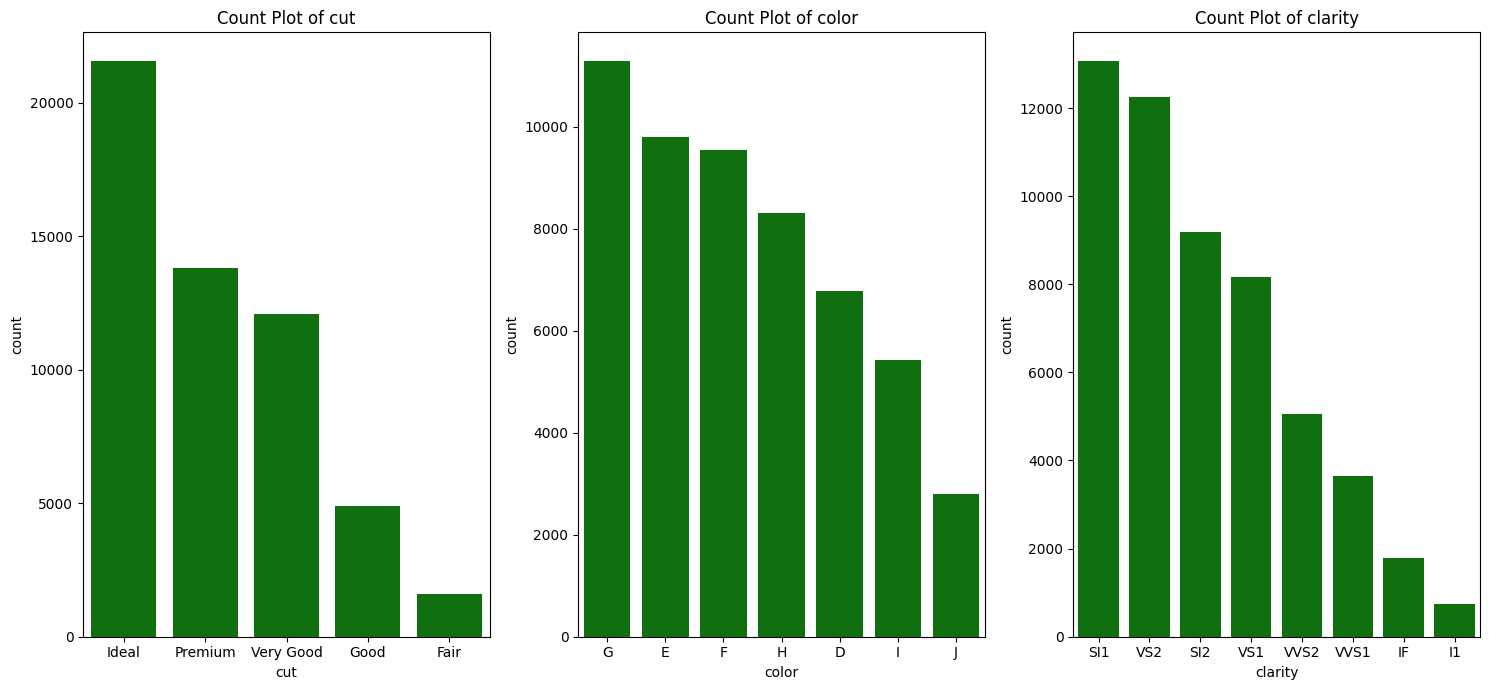

In [20]:
##Count plots for categorical columns (cut, color and clarity)
count_plots = ['cut', 'color', 'clarity']
plt.figure(figsize=(15, 7))
for i, col in enumerate(count_plots):
    plt.subplot(1, 3, i+1)
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, color='green')
    plt.title(f"Count Plot of {col}")
    plt.tight_layout()


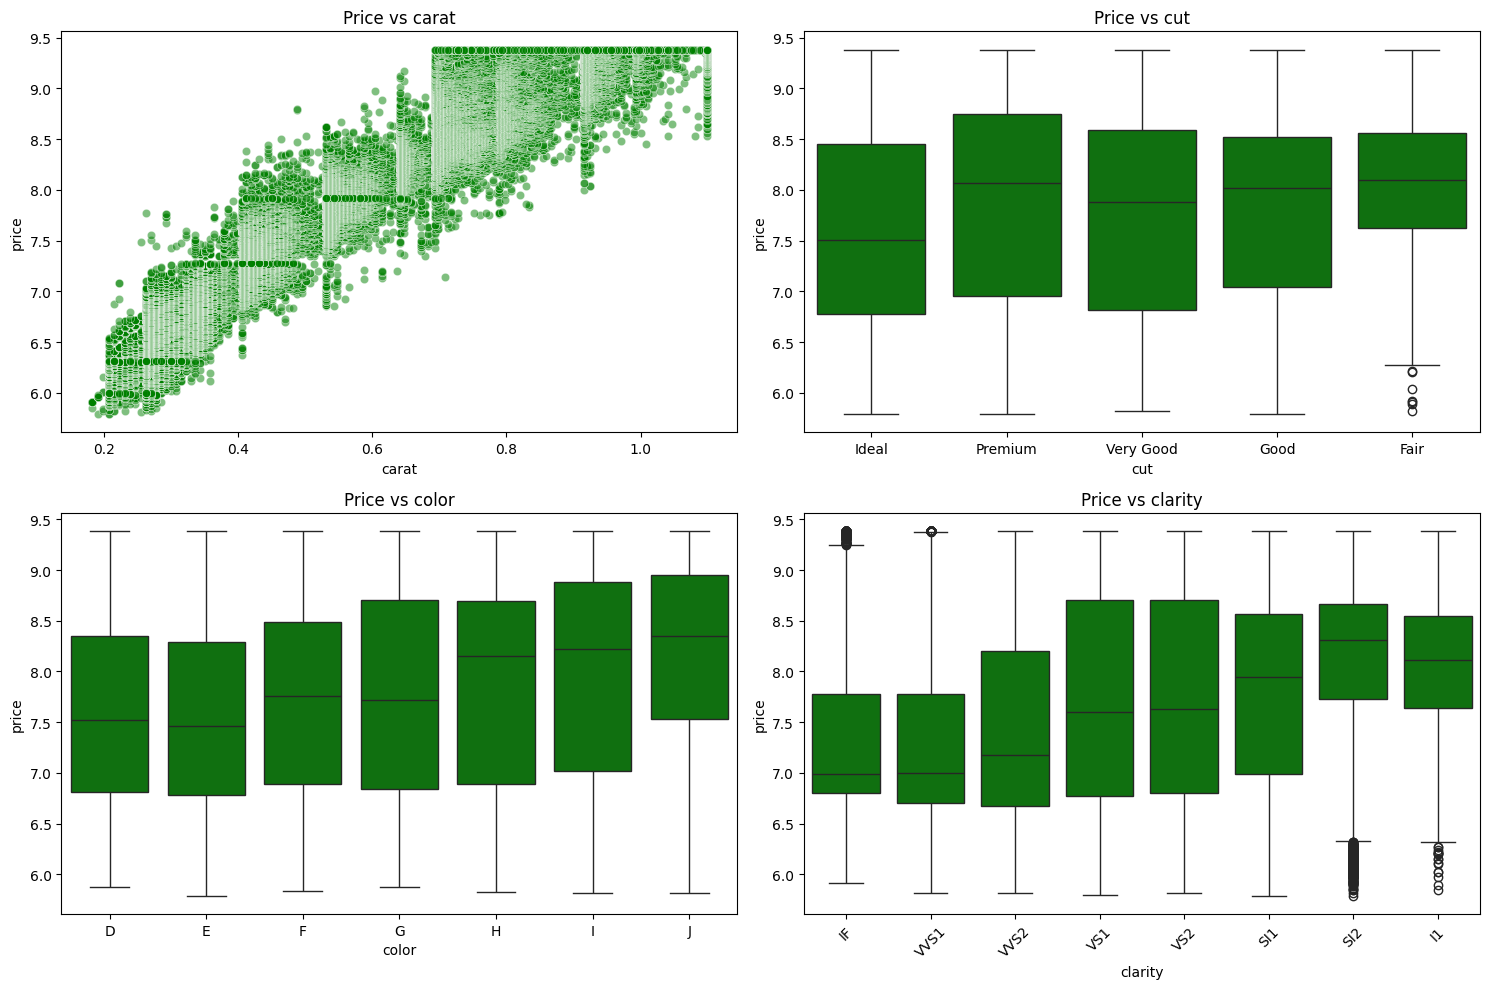

In [21]:
##Price variation with carat, cut, color, clarity using boxplots

plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
sns.scatterplot(data = data, x = 'carat', y = 'price', alpha = 0.5, color='green')
plt.title("Price vs carat")

plt.subplot(2,2,2)
sns.boxplot(data = data, x = 'cut', y = 'price', order = ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'], color='green')
plt.title("Price vs cut")

plt.subplot(2,2,3)
sns.boxplot(data = data, x = 'color', y = 'price', order = ['D', 'E', 'F', 'G', 'H', 'I', 'J'], color='green')
plt.title("Price vs color")

plt.subplot(2,2,4)
sns.boxplot(data = data, x = 'clarity', y = 'price', order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'], color='green')
plt.title("Price vs clarity")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Correlation for numerical features')

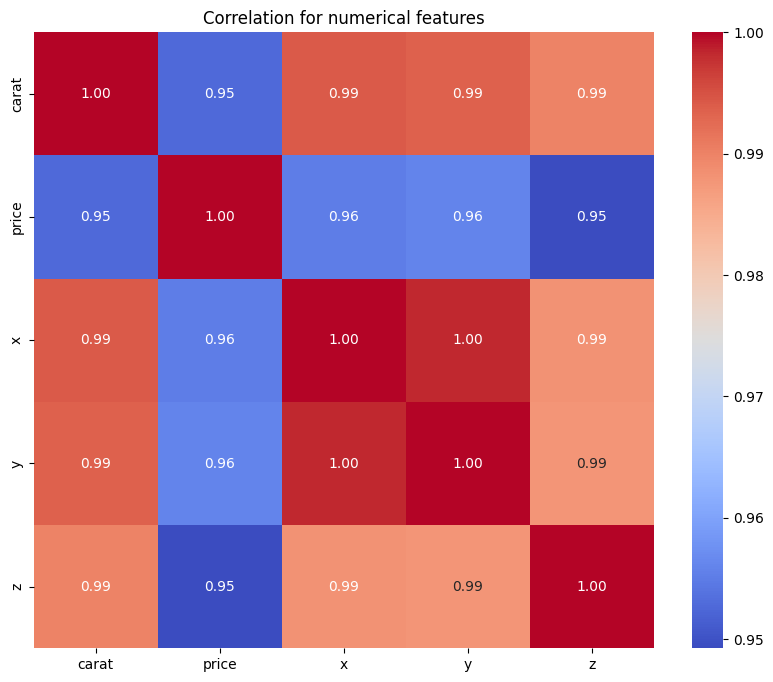

In [22]:
##Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation for numerical features")
    

Text(0.5, 1.0, 'Scatter plot for Numerical features')

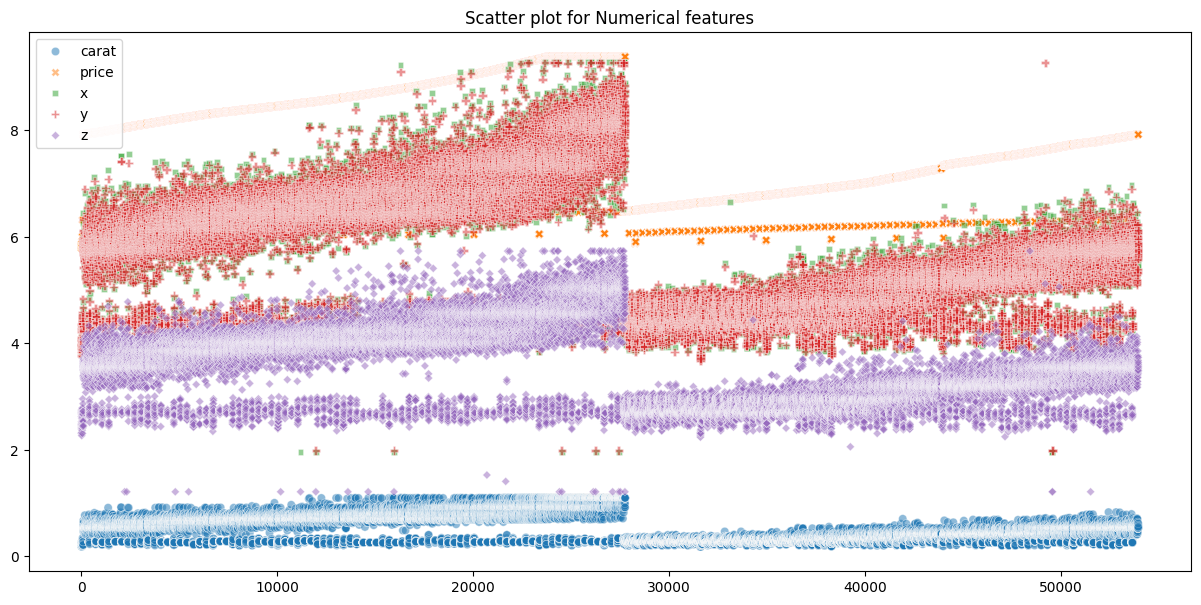

In [24]:
##Scatterplot matrix for carat, x, y, z, and price
scatter_plot = ['carat', 'price', 'x', 'y', 'z']
plt.figure(figsize=(15, 7))
sns.scatterplot(data[scatter_plot], alpha = 0.5)
plt.title("Scatter plot for Numerical features")

Text(0.5, 1.0, 'Pairwise relationship of Numerical features')

<Figure size 1500x1000 with 0 Axes>

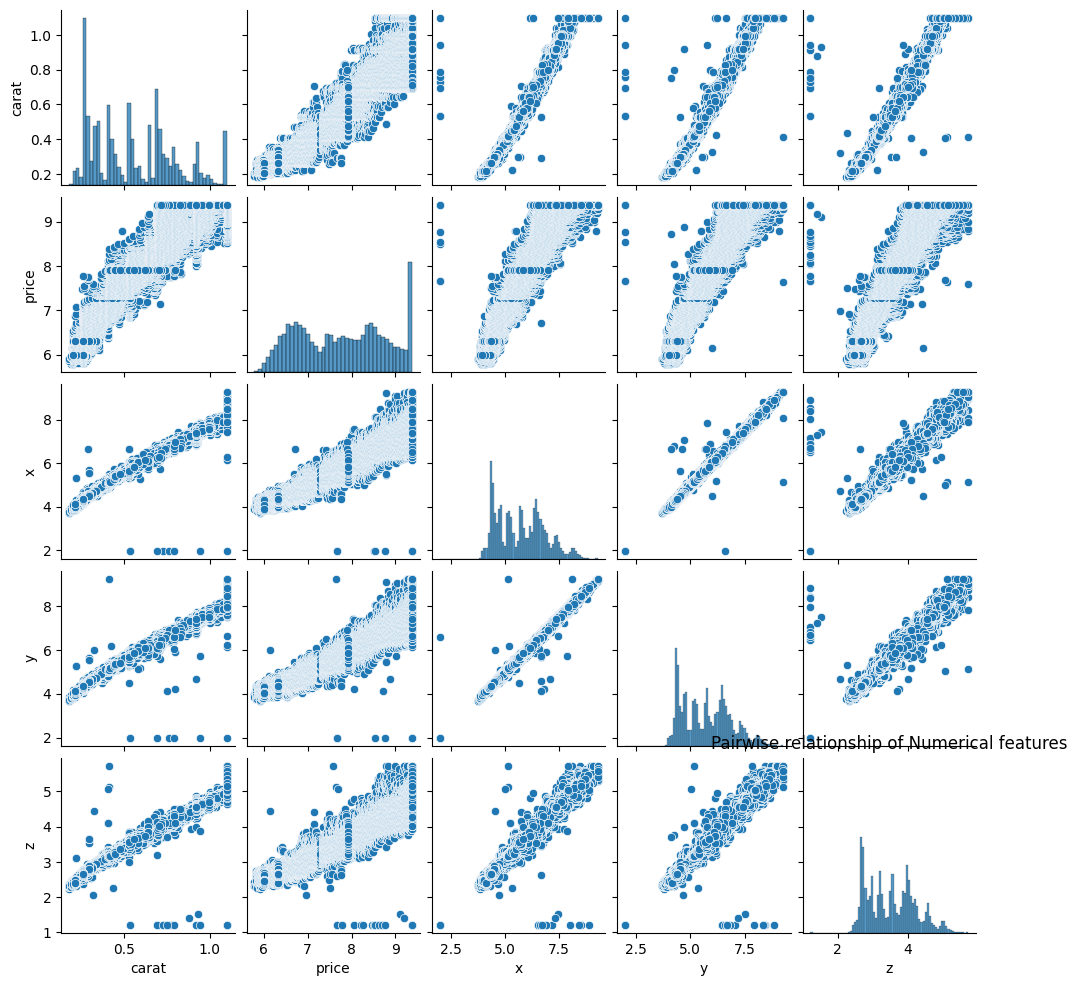

In [25]:
##Pairwise relationships using sns.pairplot()

plt.figure(figsize=(15, 10))
sns.pairplot(data[numerical_features], height=2)
plt.title("Pairwise relationship of Numerical features")

Text(0.5, 1.0, 'Carat vs. price regression lineplot')

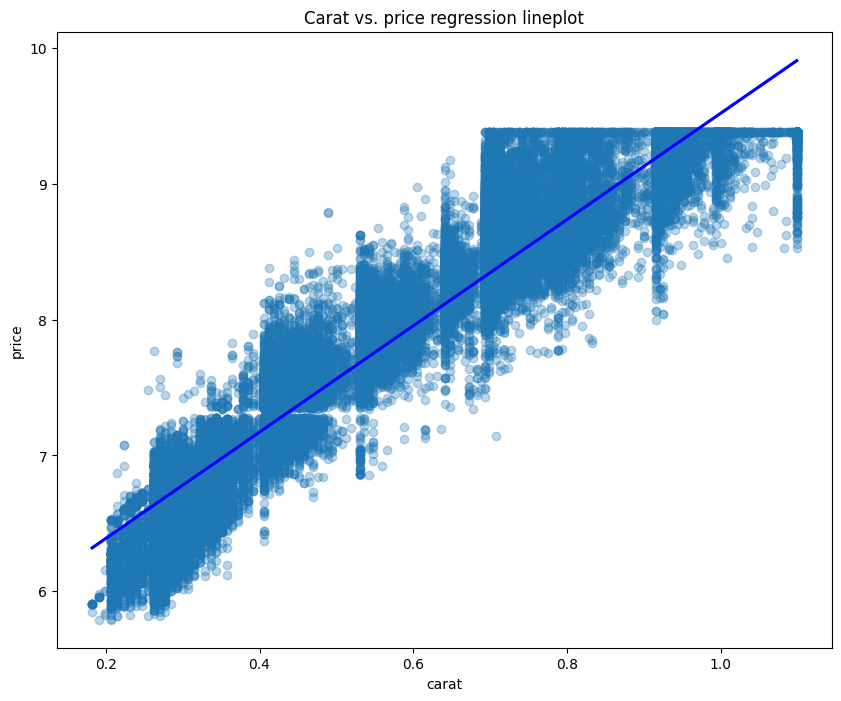

In [27]:
##Carat vs. price regression lineplot
plt.figure(figsize=(10, 8))
sns.regplot(data=data, x = 'carat', y = 'price', scatter_kws={'alpha' : 0.3}, line_kws={'color': 'blue'})
plt.title("Carat vs. price regression lineplot")

/var/folders/jz/wm_447d1669_v407wzt0rbs40000gn/T/ipykernel_43585/48627823.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = data, x = 'color', y = 'price', order = ['D', 'E', 'F', 'G', 'H', 'I', 'J'], palette ='plasma')


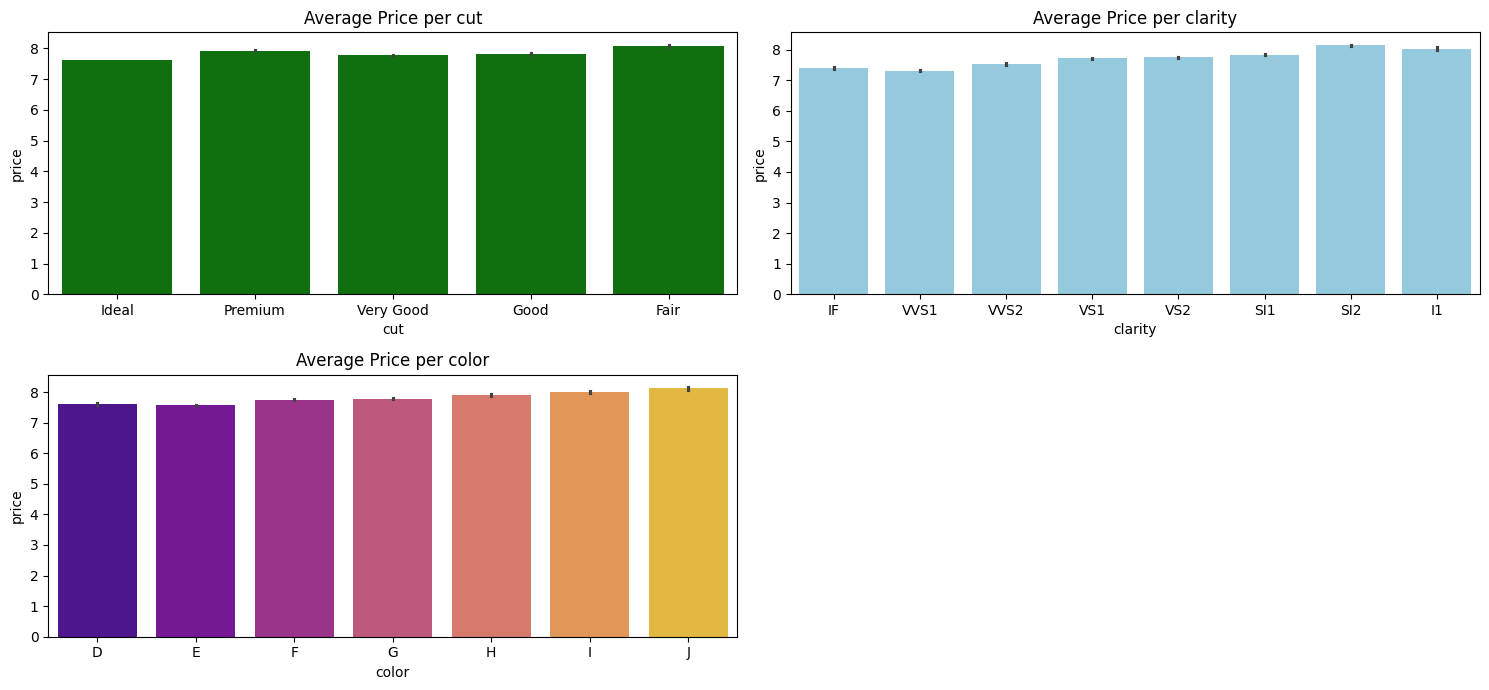

In [28]:
##Average price per cut, color, clarity categories using bar plots
plt.figure(figsize=(15, 7))
plt.subplot(2,2,1)
sns.barplot(data = data, x = 'cut', y = 'price', order = ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'], color='green')
plt.title("Average Price per cut")

plt.subplot(2,2,2)
sns.barplot(data = data, x = 'clarity', y = 'price', order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'], color='skyblue')
plt.title("Average Price per clarity")

plt.subplot(2,2,3)
sns.barplot(data = data, x = 'color', y = 'price', order = ['D', 'E', 'F', 'G', 'H', 'I', 'J'], palette ='plasma')
plt.title("Average Price per color")

plt.tight_layout()
plt.show()

In [29]:
data['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [30]:
data['clarity'].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [31]:
data['color'].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

ENCODING CATEGORICAL COLUMNS (cut, clarity, color)

In [32]:
cut_order = ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']

data['cut_encoded'] = data['cut'].astype(pd.CategoricalDtype(categories=cut_order, ordered=True)).cat.codes
data['clarity_encoded'] = data['clarity'].astype(pd.CategoricalDtype(categories=clarity_order, ordered=True)).cat.codes
data['color_encoded'] = data['color'].astype(pd.CategoricalDtype(categories=color_order, ordered=True)).cat.codes


In [34]:
data.drop(['cut','clarity','color'], axis = 1, inplace=True)

In [35]:
data

,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded
0,0.207014,61.50,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,9.63495,0,6,1
1,0.190620,59.80,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,8.92815,1,5,1
2,0.207014,58.75,63.5,5.793014,4.05,4.07,2.31,38.076885,27.983657,9.37860,3,3,1
3,0.254642,62.40,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,11.08545,1,4,5
4,0.270027,63.30,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,11.94875,3,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,60.80,57.0,7.922261,5.75,5.76,3.50,115.920000,14.607978,20.14250,0,5,0
53936,0.542324,63.10,55.0,7.922261,5.69,5.75,3.61,118.110175,14.607978,20.64920,3,5,0
53937,0.530628,62.80,60.0,7.922261,5.66,5.68,3.56,114.449728,14.929965,20.18520,2,5,0
53938,0.620576,61.00,58.0,7.922261,6.15,6.12,3.74,140.766120,12.765970,22.94490,1,6,4


MODEL BUILDING BASED ON 4 MACHINE LEARNING REGRESSION ALGORITHMS AND 1 DEEP LEARNING ARTIFICIAL NEURAL NETWORK

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
data

,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded
0,0.207014,61.50,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,9.63495,0,6,1
1,0.190620,59.80,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,8.92815,1,5,1
2,0.207014,58.75,63.5,5.793014,4.05,4.07,2.31,38.076885,27.983657,9.37860,3,3,1
3,0.254642,62.40,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,11.08545,1,4,5
4,0.270027,63.30,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,11.94875,3,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,60.80,57.0,7.922261,5.75,5.76,3.50,115.920000,14.607978,20.14250,0,5,0
53936,0.542324,63.10,55.0,7.922261,5.69,5.75,3.61,118.110175,14.607978,20.64920,3,5,0
53937,0.530628,62.80,60.0,7.922261,5.66,5.68,3.56,114.449728,14.929965,20.18520,2,5,0
53938,0.620576,61.00,58.0,7.922261,6.15,6.12,3.74,140.766120,12.765970,22.94490,1,6,4


a. Random Forest

In [38]:
##Define Xtrain, Xtest, ytrain, ytest
X = data.drop('price', axis = 1)
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
##Define and train Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)    
r2 = r2_score(y_test, y_pred)
print("Random Forest Regression Results:")
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2:', r2)

Random Forest Regression Results:
Mean Absolute Error: 0.022421641161260643
Mean Squared Error: 0.0018359551790936074
Root Mean Squared Error: 0.04284804755287699
R2: 0.9981240927654025


b. Decision Tree

In [39]:
##Define Xtrain, Xtest, ytrain, ytest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
##Define and train Decision Tree Regressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred=dt.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)    
r2 = r2_score(y_test, y_pred)
print("Decision Tree Regression Results:")
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)

Decision Tree Regression Results:
Mean Absolute Error: 0.029982986924086057
Mean Squared Error: 0.004284853113933643
Root Mean Squared Error: 0.06545878943223471
R2 Score: 0.9956219045828864


c. Linear Regression

In [40]:
##Define Xtrain, Xtest, ytrain, ytest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
##Define and train Linear Regression
lr=LinearRegression()
lr.fit(X_train, y_train)
y_pred=lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)    
r2 = r2_score(y_test, y_pred)
print("Linear Regression Results:")
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)

Linear Regression Results:
Mean Absolute Error: 0.09959411823040266
Mean Squared Error: 0.018186993605956863
Root Mean Squared Error: 0.1348591621135059
R2 Score: 0.9814172408621452


d. K-Nearest Neighbors

In [41]:
##Define Xtrain, Xtest, ytrain, ytest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
##Define and train K-Nearest Neighbors (KNN) Regressor
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)    
r2 = r2_score(y_test, y_pred)
print("K-Nearest Neighbors Regression (KNN) Results:")
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R Square Score:', r2)


K-Nearest Neighbors Regression (KNN) Results:
Mean Absolute Error: 0.07928614356024985
Mean Squared Error: 0.012681682382476512
Root Mean Squared Error: 0.11261297608391545
R Square Score: 0.9870423526679445


In [42]:
import pickle
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

e. Artificial Neural Network

In [43]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [44]:
X_train.shape

(43152, 12)

In [45]:
##Convert data to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

batch_size = 32
num_epochs = 50
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [46]:
print("Checking X_train_tensor for NaNs/Infs:", torch.isnan(X_train_tensor).any() or torch.isinf(X_train_tensor).any())
print("Checking y_train_tensor for NaNs/Infs:", torch.isnan(y_train_tensor).any() or torch.isinf(y_train_tensor).any())


Checking X_train_tensor for NaNs/Infs: tensor(False)
Checking y_train_tensor for NaNs/Infs: tensor(False)


In [47]:
##Inititate the class for model
class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegression, self).__init__() # Initialising parent class
        # Define different layers
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 16)
        self.layer4 = nn.Linear(16, 1)        
    def forward(self, x):
      x=self.layer1(x)
      x=torch.relu(x) # Add the activation function
      x=self.layer2(x)
      x=torch.relu(x)
      x=self.layer3(x)
      x=torch.relu(x)
      x=self.layer4(x)
      return x

## Training the model
n_samples, n_features = X_train_tensor.shape
input_size = n_features
output_size = 1
model=LinearRegression(input_size,output_size)

## Define Learning rate, Loss and optimizer
learning_rate = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Training loop
for epoch in range(num_epochs):
    for i, (X_train_tensor, y_train_tensor) in enumerate(train_loader):
    # Forward pass and loss
        y_predicted = model(X_train_tensor)
        loss = criterion(y_predicted, y_train_tensor)

        # Backward pass and update
        loss.backward()
        optimizer.step()

        # zero grad before new step
        optimizer.zero_grad()

    if (epoch+1) % 10 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')

epoch: 10, loss = 0.0045
epoch: 20, loss = 0.0104
epoch: 30, loss = 0.0119
epoch: 40, loss = 0.0123
epoch: 50, loss = 0.0069


--------------- DIAMOND PRICE PREDICTION STREAMLIT APP -----------

MARKET SEGMENTATION

In [104]:
data.drop(['Cluster', 'Segment'], axis = 1, inplace=True)
data

,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded
0,0.207014,61.50,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,9.63495,0,6,1
1,0.190620,59.80,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,8.92815,1,5,1
2,0.207014,58.75,63.5,5.793014,4.05,4.07,2.31,38.076885,27.983657,9.37860,3,3,1
3,0.254642,62.40,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,11.08545,1,4,5
4,0.270027,63.30,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,11.94875,3,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,60.80,57.0,7.922261,5.75,5.76,3.50,115.920000,14.607978,20.14250,0,5,0
53936,0.542324,63.10,55.0,7.922261,5.69,5.75,3.61,118.110175,14.607978,20.64920,3,5,0
53937,0.530628,62.80,60.0,7.922261,5.66,5.68,3.56,114.449728,14.929965,20.18520,2,5,0
53938,0.620576,61.00,58.0,7.922261,6.15,6.12,3.74,140.766120,12.765970,22.94490,1,6,4


K-Means Clustering to find the optimal K

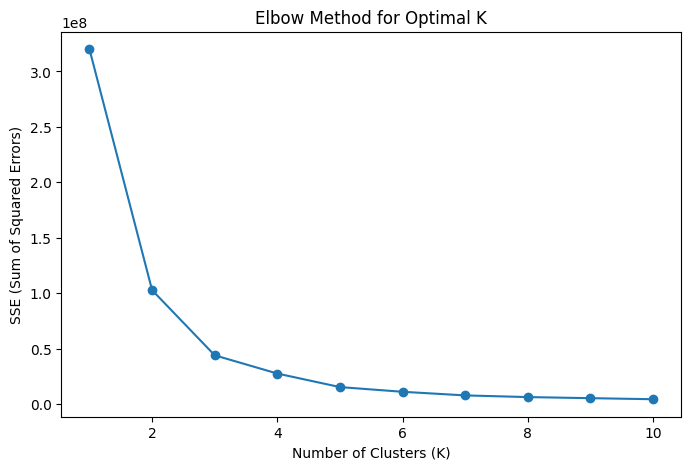

In [105]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = [] # Sum of squared errors
for k in range(1, 11): ##Checking optimal K from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    sse.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method for Optimal K')
plt.show()

In [112]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(data)


ANALYSE KMEANS USING SILHOUETTE SCORE 

In [ ]:
##Silhoutte score
from sklearn.metrics import silhouette_score
print('Silhouette_Score:', silhouette_score(data, labels_kmeans))

Silhouette_Score: 0.6286408257419873


In [114]:
##Save the Kmeans pickle file 
import pickle
with open('kmeans_final.pkl', 'wb') as h:
    pickle.dump(kmeans_final, h)

CLUSTERING

In [115]:
data['Cluster'] = kmeans_final.labels_
data


,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded,Cluster
0,0.207014,61.50,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,9.63495,0,6,1,1
1,0.190620,59.80,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,8.92815,1,5,1,1
2,0.207014,58.75,63.5,5.793014,4.05,4.07,2.31,38.076885,27.983657,9.37860,3,3,1,1
3,0.254642,62.40,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,11.08545,1,4,5,1
4,0.270027,63.30,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,11.94875,3,6,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,60.80,57.0,7.922261,5.75,5.76,3.50,115.920000,14.607978,20.14250,0,5,0,0
53936,0.542324,63.10,55.0,7.922261,5.69,5.75,3.61,118.110175,14.607978,20.64920,3,5,0,0
53937,0.530628,62.80,60.0,7.922261,5.66,5.68,3.56,114.449728,14.929965,20.18520,2,5,0,0
53938,0.620576,61.00,58.0,7.922261,6.15,6.12,3.74,140.766120,12.765970,22.94490,1,6,4,0


In [116]:
data.groupby('Cluster').mean()

,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded
Cluster,,,,,,,,,,,,,
0,0.671104,61.789916,57.736859,8.375589,6.306707,6.306145,3.896425,156.763222,12.653990,24.665573,1.256599,4.420648,2.715207
1,0.339720,61.709750,57.014650,6.878375,4.731237,4.739379,2.919289,66.936076,21.007315,13.925198,0.906119,3.343891,2.217163
2,0.989414,61.767354,58.089208,9.233364,7.682489,7.669553,4.741348,281.904016,9.388195,36.499709,1.299103,4.728849,3.641106


In [117]:
data.groupby('Cluster').mean().sort_values('price', ascending=False)

,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded
Cluster,,,,,,,,,,,,,
2,0.989414,61.767354,58.089208,9.233364,7.682489,7.669553,4.741348,281.904016,9.388195,36.499709,1.299103,4.728849,3.641106
0,0.671104,61.789916,57.736859,8.375589,6.306707,6.306145,3.896425,156.763222,12.653990,24.665573,1.256599,4.420648,2.715207
1,0.339720,61.709750,57.014650,6.878375,4.731237,4.739379,2.919289,66.936076,21.007315,13.925198,0.906119,3.343891,2.217163


In [118]:
## Mapping the labels
cluster_labels = {
    0: "Mid-range Balanced Diamonds",
    1: "Affordable Small Diamonds",
    2: "Premium Heavy Diamonds"
}
data['Segment'] = data['Cluster'].map(cluster_labels)
data

,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded,Cluster,Segment
0,0.207014,61.50,55.0,5.789960,3.95,3.98,2.43,38.202030,27.968908,9.63495,0,6,1,1,Affordable Small Diamonds
1,0.190620,59.80,61.0,5.789960,3.89,3.84,2.31,34.505856,30.374301,8.92815,1,5,1,1,Affordable Small Diamonds
2,0.207014,58.75,63.5,5.793014,4.05,4.07,2.31,38.076885,27.983657,9.37860,3,3,1,1,Affordable Small Diamonds
3,0.254642,62.40,58.0,5.814131,4.20,4.23,2.63,46.724580,22.832547,11.08545,1,4,5,1,Affordable Small Diamonds
4,0.270027,63.30,58.0,5.817111,4.34,4.35,2.75,51.917250,21.542691,11.94875,3,6,6,1,Affordable Small Diamonds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,60.80,57.0,7.922261,5.75,5.76,3.50,115.920000,14.607978,20.14250,0,5,0,0,Mid-range Balanced Diamonds
53936,0.542324,63.10,55.0,7.922261,5.69,5.75,3.61,118.110175,14.607978,20.64920,3,5,0,0,Mid-range Balanced Diamonds
53937,0.530628,62.80,60.0,7.922261,5.66,5.68,3.56,114.449728,14.929965,20.18520,2,5,0,0,Mid-range Balanced Diamonds
53938,0.620576,61.00,58.0,7.922261,6.15,6.12,3.74,140.766120,12.765970,22.94490,1,6,4,0,Mid-range Balanced Diamonds


In [119]:
data['Segment'].value_counts()

Segment
Affordable Small Diamonds      25543
Mid-range Balanced Diamonds    21707
Premium Heavy Diamonds          6690
Name: count, dtype: int64

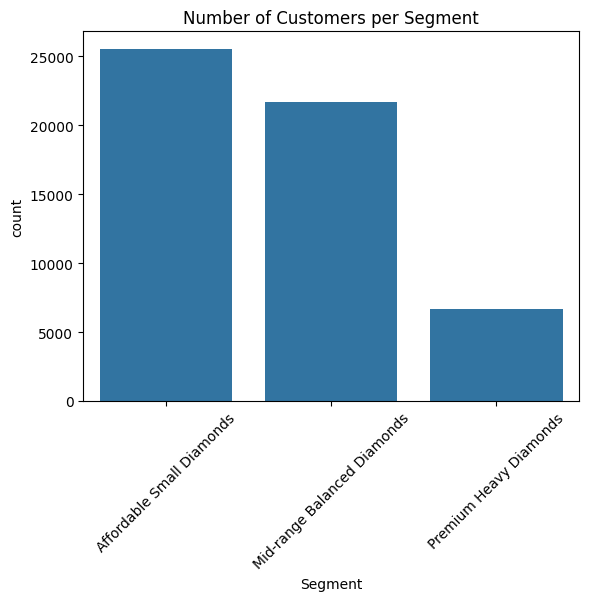

In [120]:
sns.countplot(x='Segment', data=data, order=data['Segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Number of Customers per Segment")
plt.show()

/var/folders/jz/wm_447d1669_v407wzt0rbs40000gn/T/ipykernel_43585/3847663990.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = data, x = 'carat', y = 'Segment', palette ='plasma')


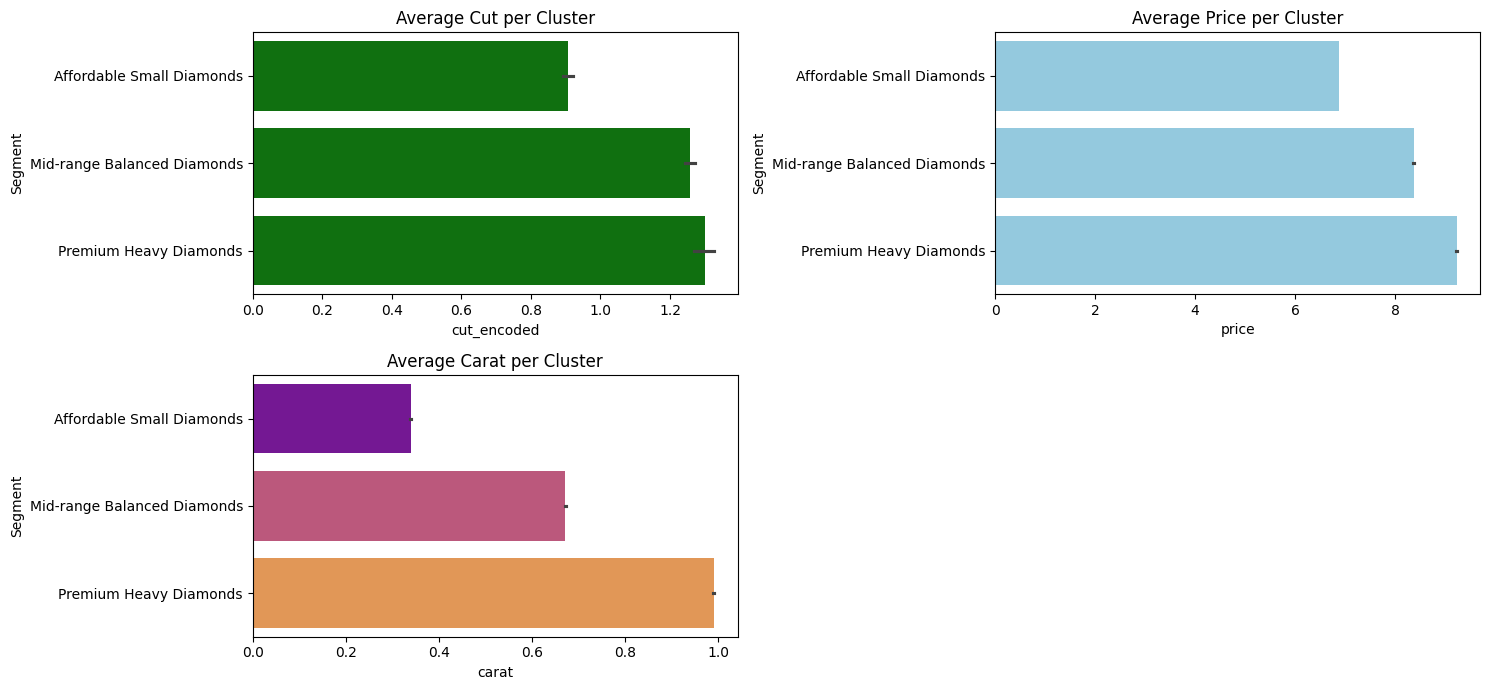

In [121]:
##Average price per cut, color, clarity categories using bar plots
plt.figure(figsize=(15, 7))
plt.subplot(2,2,1)
sns.barplot(data = data, x = 'cut_encoded', y = 'Segment', color='green')
plt.title("Average Cut per Cluster")

plt.subplot(2,2,2)
sns.barplot(data = data, x = 'price', y = 'Segment', color='skyblue')
plt.title("Average Price per Cluster")

plt.subplot(2,2,3)
sns.barplot(data = data, x = 'carat', y = 'Segment', palette ='plasma')
plt.title("Average Carat per Cluster")

plt.tight_layout()
plt.show()

In [125]:
data.describe()

,carat,depth,table,price,x,y,z,Volume,Price per Carat,Dimension ratio,cut_encoded,clarity_encoded,color_encoded,Cluster
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.553658,61.749156,57.438561,7.772978,5.731285,5.733311,3.538500,129.746854,16.204617,21.047274,1.095903,3.948980,2.594197,0.721598
std,0.240637,1.270254,2.161139,0.988826,1.119956,1.111950,0.692494,76.289863,5.324998,8.226113,1.116600,1.647136,1.701105,0.670042
min,0.182322,58.750000,51.500000,5.789960,1.965000,1.990000,1.215000,4.751075,7.762101,2.402662,0.000000,0.000000,0.000000,0.000000
25%,0.336472,61.000000,56.000000,6.857514,4.710000,4.720000,2.910000,65.160108,11.893070,13.778850,0.000000,3.000000,1.000000,0.000000
50%,0.530628,61.800000,57.000000,7.784057,5.700000,5.710000,3.530000,114.808572,14.730873,20.128500,1.000000,4.000000,3.000000,1.000000
75%,0.712950,62.500000,59.000000,8.580215,6.540000,6.540000,4.040000,170.841804,20.486952,26.183250,2.000000,5.000000,4.000000,1.000000
max,1.098612,64.750000,63.500000,9.383169,9.285000,9.270000,5.735000,493.622633,32.404742,53.206462,4.000000,7.000000,6.000000,2.000000


In [123]:
##Save the segmented pickle file
with open('data.pkl', 'wb') as i:
    pickle.dump(data, i)

--------------- DIAMOND CLUSTER PREDICTION STREAMLIT APP -----------